<a href="https://colab.research.google.com/github/Vishalization/optimisation_resNet50/blob/main/optimization_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#extract Dataset
import zipfile
import os

zip_path = "/content/drive/MyDrive/skin_split.rar"

extract_path = "/content/dataset"
os.makedirs(extract_path, exist_ok=True)

!unrar x "{zip_path}" "{extract_path}"

In [3]:
#Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

from tensorflow.keras.optimizers import Adam, AdamW, SGD

from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.utils.class_weight import compute_class_weight

In [4]:
#Fix random seed
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
#Dataset Paths
train_dir = "/content/dataset/skin_split/train"
test_dir = "/content/dataset/skin_split/test"

In [6]:
#Baseline Data Generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [7]:
#Train Generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

Found 6411 images belonging to 7 classes.


In [8]:
#Val Generator
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

Found 1599 images belonging to 7 classes.


In [9]:
#Test Generator
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2005 images belonging to 7 classes.


In [10]:
#Class Weight
class_labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(4.3820915926179085), 1: np.float64(2.7837603126356925), 2: np.float64(1.3009334415584415), 3: np.float64(12.376447876447877), 4: np.float64(1.2863162118780096), 5: np.float64(0.2133870323525496), 6: np.float64(10.06436420722135)}


In [11]:
#Build Baseline Model
from tensorflow.keras.applications import ResNet50

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.models import Model

from tensorflow.keras.regularizers import l2

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Fine-tune entire network
base_model.trainable = True

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation='relu',
    kernel_regularizer=l2(0.001)
)(x)

x = Dropout(0.5)(x)

output = Dense(
    7,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [12]:
#Compile Baseline Model
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
#Callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_baseline_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [14]:
#train Baseline
history_baseline = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[reduce_lr, early_stop, checkpoint]
)

Epoch 1/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.1943 - loss: 2.5841
Epoch 1: val_accuracy improved from None to 0.11132, saving model to best_baseline_model.keras

Epoch 1: finished saving model to best_baseline_model.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 185s 594ms/step - accuracy: 0.2535 - loss: 2.5121 - val_accuracy: 0.1113 - val_loss: 2.6911 - learning_rate: 1.0000e-05
Epoch 2/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.4166 - loss: 1.8874
Epoch 2: val_accuracy did not improve from 0.11132
201/201 ━━━━━━━━━━━━━━━━━━━━ 79s 391ms/step - accuracy: 0.4651 - loss: 1.8376 - val_accuracy: 0.1094 - val_loss: 3.8567 - learning_rate: 1.0000e-05
Epoch 3/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.5684 - loss: 1.5366
Epoch 3: val_accuracy improved from 0.11132 to 0.12883, saving model to best_baseline_model.keras

Epoch 3: finished saving model to best_baseline_model.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 82s 405ms/step - accuracy: 0.5723 - loss: 1.

In [26]:
df=pd.DataFrame(model.history.history)
df.to_csv('hist.csv')

<Axes: >

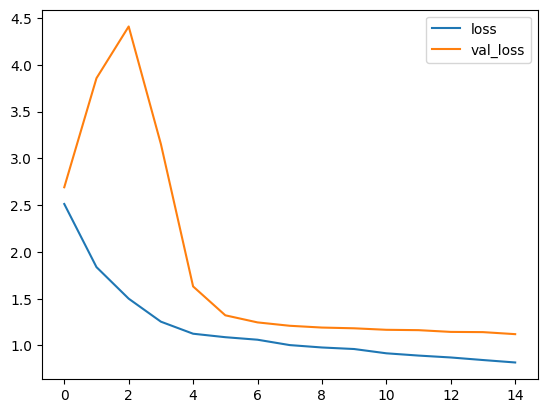

In [27]:
metrics = pd.DataFrame(model.history.history)
metrics[["loss","val_loss"]].plot()



<Axes: >

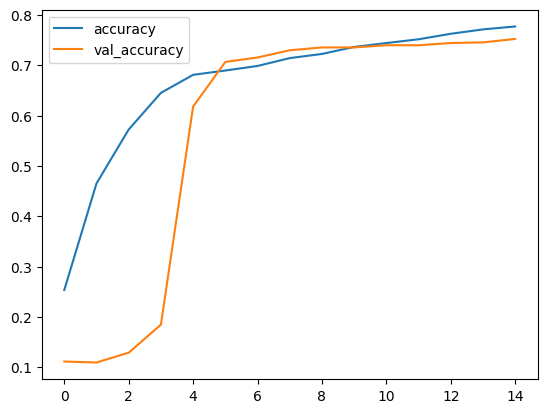

In [28]:
metrics[["accuracy","val_accuracy"]].plot()

In [29]:
model.evaluate(test_generator)

63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 267ms/step - accuracy: 0.7561 - loss: 1.1296


[1.1296120882034302, 0.7561097145080566]

In [31]:
predictions = model.predict(test_generator, verbose=1)
predictions = predictions.argmax(axis=1)

test_labels = test_generator.classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 249ms/step


In [32]:


import sklearn
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(test_labels, predictions)



Normalized confusion matrix


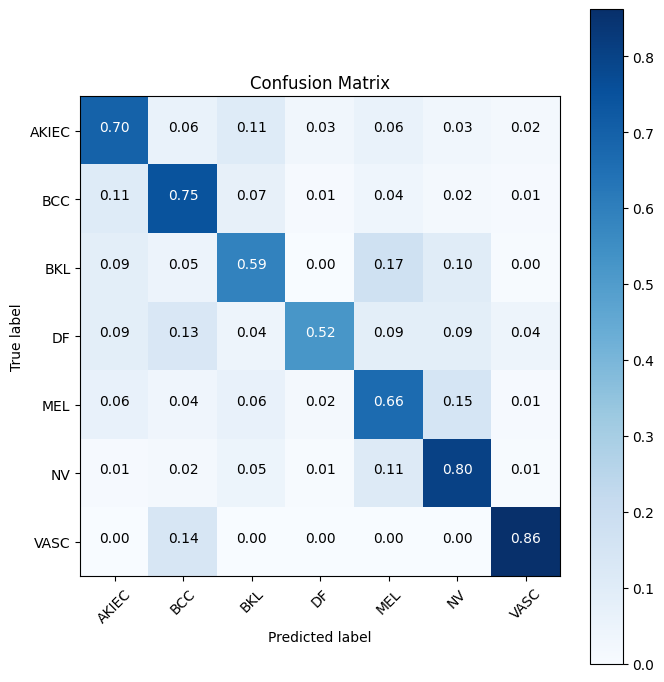

In [33]:
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=True,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
        print(cm)

    plt.figure(figsize=(7,7))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


cm_plot_labels =['AKIEC','BCC','BKL','DF','MEL','NV','VASC']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix', normalize=True)

In [34]:
!pip install disarray

import disarray

# Instantiate the confusion matrix DataFrame with index and columns
#cm = confusion_matrix(a,b)
df = pd.DataFrame(cm, index= ['AKIEC','BCC','BKL','DF','MEL','NV','VASC'], columns=['AKIEC','BCC','BKL','DF','MEL','NV','VASC'])
df.da.export_metrics()



,AKIEC,BCC,BKL,DF,MEL,NV,VASC,micro-average
accuracy,0.961097,0.960100,0.909227,0.987531,0.863840,0.838903,0.991521,0.930317
f1,0.541176,0.658120,0.586364,0.489796,0.520211,0.869811,0.746269,0.756110
false_discovery_rate,0.557692,0.412214,0.413636,0.538462,0.572254,0.053509,0.342105,0.243890
false_negative_rate,0.303030,0.252427,0.413636,0.478261,0.336323,0.195377,0.137931,0.243890
false_positive_rate,0.029912,0.028391,0.050980,0.007064,0.111111,0.091867,0.006579,0.040648
negative_predictive_value,0.989479,0.986126,0.949020,0.994442,0.954792,0.697110,0.997966,0.959352
positive_predictive_value,0.442308,0.587786,0.586364,0.461538,0.427746,0.946491,0.657895,0.756110
precision,0.442308,0.587786,0.586364,0.461538,0.427746,0.946491,0.657895,0.756110
recall,0.696970,0.747573,0.586364,0.521739,0.663677,0.804623,0.862069,0.756110
sensitivity,0.696970,0.747573,0.586364,0.521739,0.663677,0.804623,0.862069,0.756110
